In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import numpy as np
import os

import importlib
import utils

importlib.reload(utils)
argFile = 'parameters.json'
try:
    del args
except NameError:
    pass
args = utils.loadJson(argFile)
if args.LoRA:
    args.method = "LoRA"
elif args.wt:
    args.method = "LoRA_full_rank"
else :
    args.method = "standard"

In [2]:
# Load the simulation
path_to_sim = os.path.join(args.path_to_res_folder, f"sim_K={args.K}_M={args.M}.csv")
sim = pd.read_csv(path_to_sim)

constraint = (
        (sim["L"] == args.L) &
        (sim["beta"] == args.beta) &
        (sim["method"] == args.method) &
        (sim["rho"] == args.rho) &
        (sim["M"] == args.M) &
        (sim["K"] == args.K) &
        (sim["N"] == args.N)
    )

df = sim[constraint]
if df.empty:
    print("file is empty !")

path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"sim_K={args.K}_M={args.M}_ODES.csv")
sim_ODEs = pd.read_csv(path_to_sim_ODEs)
constraint_ODE = (
    (sim_ODEs["L"] == args.L) &
    (sim_ODEs["beta"] == args.beta) &
    (sim_ODEs["method"] == args.method) &
    (sim_ODEs["rho"] == args.rho) &
    (sim_ODEs["M"] == args.M) &
    (sim_ODEs["K"] == args.K) &
    (sim_ODEs["N"] == args.N)
)
df_ODES = sim_ODEs[constraint_ODE]

alpha_val = df["alpha"].iloc[0]
N_val = df["N"].iloc[0]
P = alpha_val * N_val

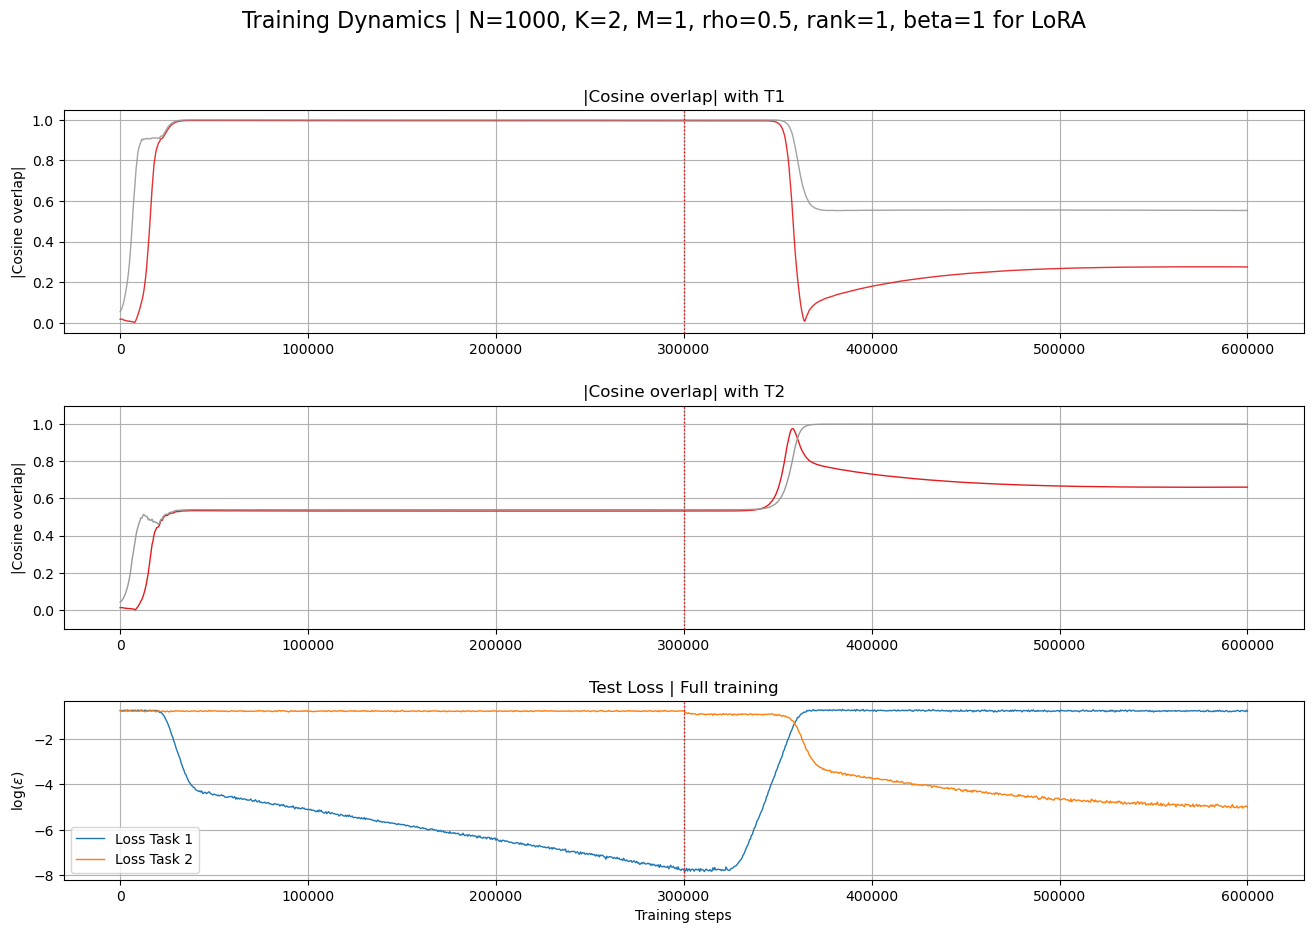

In [3]:
# Pick distinct colors for each component (i,j)
colors = cm.Set1(np.linspace(0, 1, args.K*args.M))

# --- Grid layout ---
fig = plt.figure(figsize=(16, 10))
fig.suptitle(f"Training Dynamics | N={args.N}, K={args.K}, M={args.M}, rho={args.rho}, rank={args.L}, beta={args.beta} for {args.method}", fontsize=16)
gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 0.8], hspace=0.35)

# --- Top: |Overlap T1| on all training ---
ax_t1 = fig.add_subplot(gs[0, 0])

#colors = cm.tab20(np.linspace(0, 1, K*M))

for idx, (i, j) in enumerate([(i,j) for i in range(1,args.K+1) for j in range(1,args.M+1)]):
    col = f'overlap_t1_full_{i}{j}'
    
    if col in df.columns:
        ax_t1.plot(df["steps"],
                   np.abs(df[col]),
                   lw=1,
                   color=colors[idx],
                   alpha=0.9, label=f"T1 {i}{j}")

ax_t1.set_title("|Cosine overlap| with T1")
#ax_t1.set_xlabel("Training steps")
ax_t1.set_ylabel("|Cosine overlap|")
#ax_t1.set_ylim(-0.1, 1.1)
ax_t1.axvline(x=P, linestyle=':', color='red', lw=1)
ax_t1.grid(True)
#ax_t1.legend(fontsize=9)

# --- Middle: |Overlap T2| ---
ax_t2 = fig.add_subplot(gs[1, 0])

for idx, (i, j) in enumerate([(i,j) for i in range(1,args.K+1) for j in range(1,args.M+1)]):
    col_full= f'overlap_t2_full_{i}{j}'
    color = colors[idx]
    ax_t2.plot(df["steps"],
               np.abs(df[col_full]),
               lw=1, linestyle='-', color=color, alpha=1.0,
               label=f"T2 {i}{j}")

ax_t2.set_title("|Cosine overlap| with T2")
ax_t2.set_ylabel("|Cosine overlap|")
ax_t2.set_ylim(-0.1, 1.1)
ax_t2.axvline(x=P, linestyle=':', color='red', lw=1.0)
ax_t2.grid(True)

# --- Bottom row: Test losses full training ---
ax_loss = fig.add_subplot(gs[2, 0])
ax_loss.plot(df["steps"], np.log10(df["test_loss1"]), lw=1, label="Loss Task 1")
ax_loss.plot(df["steps"], np.log10(df["test_loss2"]), lw=1, label="Loss Task 2")
ax_loss.set_title("Test Loss | Full training")
ax_loss.set_xlabel("Training steps")
ax_loss.set_ylabel(r"$\log(\epsilon)$")
ax_loss.axvline(x=P, linestyle=':', color='red', lw=1.0)
ax_loss.grid(True)
ax_loss.legend()


plt.savefig(f"training_K_{args.K}_M_{args.M}_rho_{args.rho}_rank_{args.L}_beta_{args.beta}_{args.method}.pdf")
plt.show()

/tmp/ipykernel_1869522/858405765.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


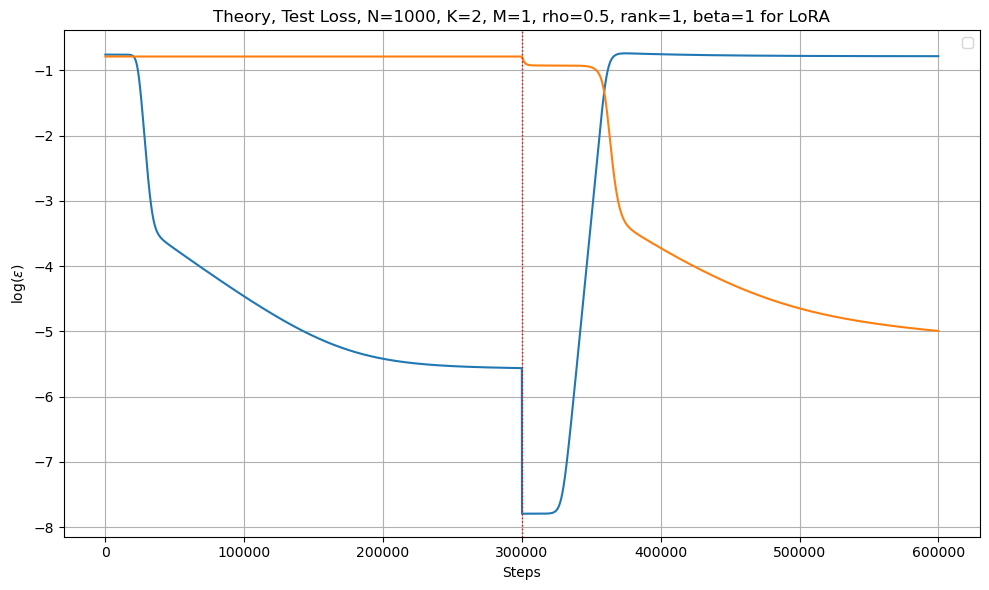

In [6]:
t_span = args.N * np.arange(0,2*args.alpha,args.integration_step)
plt.figure(figsize=(10,6))
plt.plot(t_span, np.log10(df_ODES["test_loss1"]), )
plt.plot(t_span, np.log10(df_ODES["test_loss2"]), )
plt.axvline(x=P, linestyle=':', color='red', lw=1.0)

plt.title(f"Theory, Test Loss, N={args.N}, K={args.K}, M={args.M}, rho={args.rho}, rank={args.L}, beta={args.beta} for {args.method}")
plt.xlabel("Steps")
plt.ylabel(r"$\log(\epsilon)$")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

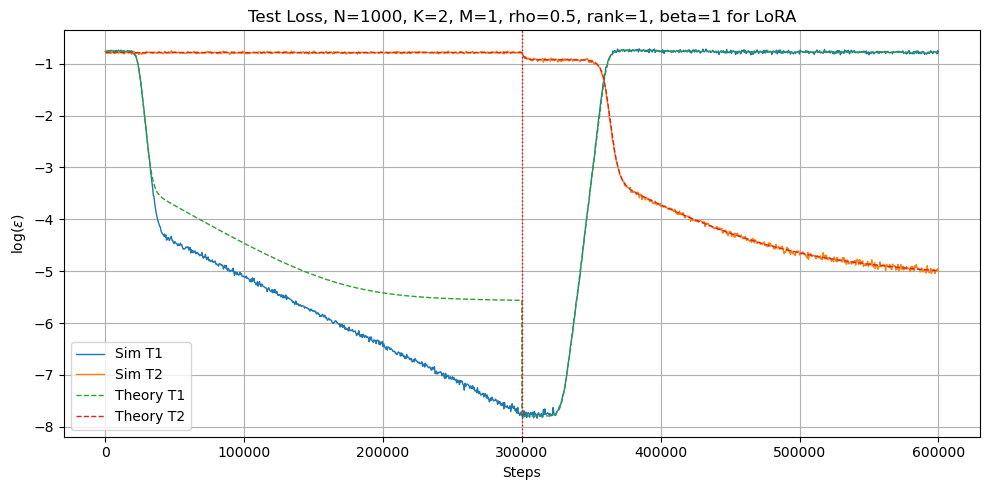

In [5]:
t_span = args.N * np.arange(0,2*args.alpha,args.integration_step)

fig, ax = plt.subplots(figsize=(10, 5))

# --- Simulation ---
ax.plot(
    df["steps"],
    np.log10(df["test_loss1"]),
    label="Sim T1",
    lw=1
)
ax.plot(
    df["steps"],
    np.log10(df["test_loss2"]),
    label="Sim T2",
    lw=1
)

# --- Theory ---
ax.plot(
    t_span,
    np.log10(df_ODES["test_loss1"]),
    "--",
    label="Theory T1",
    lw=1
)
ax.plot(
    t_span,
    np.log10(df_ODES["test_loss2"]),
    "--",
    label="Theory T2",
    lw=1
)

# --- Task boundary ---
ax.axvline(x=P, linestyle=":", color="red", lw=1)

ax.set_title(f"Test Loss, N={args.N}, K={args.K}, M={args.M}, rho={args.rho}, rank={args.L}, beta={args.beta} for {args.method}")
ax.set_xlabel("Steps")
ax.set_ylabel(r"$\log(\epsilon)$")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()